# 🚗 Analyse des Accidents de la Route en France (2012-2019)

**Projet** : Mighty Mosquitoes - Data Engineering 2025

**Objectif** : Identifier les zones à risque, les conditions accidentogènes et les tendances temporelles pour orienter les politiques de prévention routière.

---

## 📋 Table des matières

1. [📊 Introduction & Indicateurs Clés](#section1)
2. [🗺️ Analyse Géographique](#section2)
   - 2.1 [🔍 Volume vs Gravité - Analyse Approfondie](#section2.1)
3. [🌦️ Conditions Accidentogènes](#section3)
4. [⏰ Tendances Temporelles](#section4)
   - 4.1 [📉 Détection des Semaines Anormales](#section4.1)
5. [⚠️ Analyse de Risque](#section5)
6. [🔴 Cocktail Mortel (Analyse Avancée)](#section6)
7. [📅 Effet Week-end Saisonnier (Analyse Avancée)](#section7)
8. [💡 Conclusions & Recommandations](#section8)

---

## ⚙️ Configuration & Imports

In [42]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
from sqlalchemy import create_engine, text
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
from dotenv import load_dotenv
import os

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Packages importés avec succès")

✅ Packages importés avec succès


In [43]:
# Configuration de la connexion à la base de données
load_dotenv()

# Récupération des variables d'environnement
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'admin')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'db_accm')

# Création de l'engine SQLAlchemy
try:
    engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
    with engine.connect() as conn:
        result = conn.execute(text("SELECT COUNT(*) FROM ACCIDENT"))
        nb_accidents = result.scalar()
    print(f"✅ Connexion réussie à la base de données")
    print(f"📊 Nombre d'accidents dans la base : {nb_accidents:,}")
except Exception as e:
    print(f"❌ Erreur de connexion : {e}")
    engine = None
    
# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuration Matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8-darkgrid')


✅ Connexion réussie à la base de données
📊 Nombre d'accidents dans la base : 475,911


In [44]:
# Palette de couleurs cohérente
COLORS = {
    'primary': '#004c6d',      # Bleu foncé pour volumes
    'danger': '#d64545',       # Rouge pour gravité/tués
    'warning': '#f2a900',      # Jaune pour attention
    'success': '#5cb85c',      # Vert pour positif
    'info': '#00a6d6',         # Bleu clair
    'secondary': '#6c757d',    # Gris
    'neutral': '#e9ecef'       # Gris très clair
}

# Chemin vers les fichiers SQL
SQL_PATH = Path('analytics/sql')

def convert_decimal_columns(df):
    """
    Convertit les colonnes contenant des objets Decimal en float.
    
    PostgreSQL retourne des objets decimal.Decimal pour les types NUMERIC,
    ce qui peut poser problème avec NumPy/Pandas/Plotly.
    
    Args:
        df (pd.DataFrame): DataFrame à convertir
    
    Returns:
        pd.DataFrame: DataFrame avec les colonnes Decimal converties en float
    """
    from decimal import Decimal
    
    for col in df.columns:
        # Vérifier si la colonne contient des Decimal
        if df[col].dtype == 'object' and len(df) > 0:
            # Vérifier le premier élément non-null
            first_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
            if isinstance(first_val, Decimal):
                df[col] = df[col].astype(float)
    
    return df

def execute_sql_text(sql_text, description=""):
    """
    Exécute une requête SQL directe et retourne un DataFrame.
    
    Args:
        sql_text (str): Requête SQL complète
        description (str): Description pour le logging
    
    Returns:
        pd.DataFrame: Résultat de la requête avec colonnes Decimal converties en float
    """
    if engine is None:
        print(f"❌ Impossible d'exécuter la requête : pas de connexion DB")
        return pd.DataFrame()
    
    try:
        # Utiliser text() pour wrapper la requête SQL
        with engine.connect() as conn:
            result = conn.execute(text(sql_text))
            df = pd.DataFrame(result.fetchall(), columns=result.keys())
        
        # Convertir automatiquement les colonnes Decimal en float
        df = convert_decimal_columns(df)
        
        if description:
            print(f"✅ {description} : {len(df)} lignes")
        return df
    except Exception as e:
        print(f"❌ Erreur SQL : {e}")
        import traceback
        traceback.print_exc()
        return pd.DataFrame()

print("✅ Fonctions utilitaires chargées")

✅ Fonctions utilitaires chargées


---

# 📊 Section 1 : Introduction & Indicateurs Clés

Vue d'ensemble du dataset avec les métriques essentielles.

In [45]:
# Requête pour les KPI globaux
sql_kpi = """
SELECT
    'Période couverte' AS metrique,
    MIN(make_date(d.an::int, d.mois::int, d.jour::int))::TEXT || ' à ' ||
    MAX(make_date(d.an::int, d.mois::int, d.jour::int))::TEXT AS valeur
FROM DATE_ACCIDENT d
WHERE d.an IS NOT NULL AND d.mois IS NOT NULL AND d.jour IS NOT NULL
UNION ALL
SELECT
    'Nombre total d''accidents',
    COUNT(DISTINCT num_acc)::TEXT
FROM ACCIDENT
UNION ALL
SELECT
    'Nombre total de personnes impliquées',
    COUNT(*)::TEXT
FROM USAGER
UNION ALL
SELECT
    'Nombre total de tués',
    SUM(CASE WHEN grav = 'Tué' THEN 1 ELSE 0 END)::TEXT
FROM USAGER
UNION ALL
SELECT
    'Nombre total de blessés',
    SUM(CASE WHEN grav = 'Blessé' THEN 1 ELSE 0 END)::TEXT
FROM USAGER
UNION ALL
SELECT
    'Taux de mortalité global (%)',
    ROUND(100.0 * SUM(CASE WHEN grav = 'Tué' THEN 1 ELSE 0 END) /
          NULLIF(COUNT(*), 0), 2)::TEXT
FROM USAGER;
"""

df_kpi = execute_sql_text(sql_kpi, "Chargement des KPI globaux")

if not df_kpi.empty:
    kpi_dict = dict(zip(df_kpi['metrique'], df_kpi['valeur']))
    
    # Affichage visuel des KPI
    print("\n" + "="*80)
    print("                    🚨 INDICATEURS CLÉS - ACCIDENTS DE LA ROUTE")
    print("="*80 + "\n")
    
    print(f"📅 Période couverte : {kpi_dict.get('Période couverte', 'N/A')}")
    
    # Extraire les valeurs pour éviter les backslash dans les f-strings
    nb_acc = kpi_dict.get("Nombre total d'accidents", 'N/A')
    nb_pers = kpi_dict.get('Nombre total de personnes impliquées', 'N/A')
    nb_tues = kpi_dict.get('Nombre total de tués', 'N/A')
    nb_blesses = kpi_dict.get('Nombre total de blessés', 'N/A')
    taux_mort = kpi_dict.get('Taux de mortalité global (%)', 'N/A')
    
    print(f"\n🚗 {nb_acc} accidents recensés")
    print(f"👥 {nb_pers} personnes impliquées")
    print(f"💀 {nb_tues} décès")
    print(f"🏥 {nb_blesses} blessés")
    print(f"📊 Taux de mortalité : {taux_mort}%")
    
    print("\n" + "="*80 + "\n")
else:
    print("⚠️ Impossible de charger les KPI")

✅ Chargement des KPI globaux : 6 lignes

                    🚨 INDICATEURS CLÉS - ACCIDENTS DE LA ROUTE

📅 Période couverte : 2012-01-01 à 2019-12-31

🚗 475911 accidents recensés
👥 1061254 personnes impliquées
💀 28570 décès
🏥 596739 blessés
📊 Taux de mortalité : 2.69%




---

# 🗺️ Section 2 : Analyse Géographique

Identification des zones à risque : régions, départements et communes les plus accidentogènes.

In [46]:
# Top 10 des régions les plus accidentogènes
sql_regions = """
SELECT
    l.reg_name AS region,
    l.reg_code AS code_region,
    COUNT(DISTINCT a.num_acc) AS nb_accidents,
    SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
    SUM(CASE WHEN u.grav = 'Blessé hospitalisé' THEN 1 ELSE 0 END) AS nb_blesses,
    COUNT(*) AS nb_personnes_impliquees,
    ROUND(100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) / 
          NULLIF(COUNT(*), 0), 2) AS taux_mortalite_pct
FROM ACCIDENT a
INNER JOIN LIEUX l ON a.num_acc = l.num_acc
INNER JOIN USAGER u ON a.num_acc = u.num_acc
WHERE l.reg_name IS NOT NULL
GROUP BY l.reg_name, l.reg_code
ORDER BY nb_accidents DESC
LIMIT 10;
"""

df_regions = execute_sql_text(sql_regions, "Top 10 régions")
if not df_regions.empty:
    display(df_regions)

✅ Top 10 régions : 10 lignes


,region,code_region,nb_accidents,nb_tues,nb_blesses,nb_personnes_impliquees,taux_mortalite_pct
0,Île-de-France,11.00,147402,2446,0,318462,0.77
1,Provence-Alpes-Côte d'Azur,93.00,53793,2611,0,120894,2.16
2,Auvergne-Rhône-Alpes,84.00,24280,1693,0,55668,3.04
3,Rhône-Alpes,82.00,19534,1287,0,44879,2.87
4,Bretagne,53.00,19451,1353,0,42627,3.17
5,Pays de la Loire,52.00,17078,1589,0,37740,4.21
6,Nouvelle-Aquitaine,75.00,13594,1092,0,31288,3.49
7,Occitanie,76.00,11928,1143,0,27397,4.17
8,Aquitaine,72.00,11861,857,0,27161,3.16
9,Grand Est,44.00,10845,841,0,24249,3.47


In [8]:
# Visualisation : Top 10 régions (barres horizontales)
if not df_regions.empty:
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        y=df_regions['region'],
        x=df_regions['nb_accidents'],
        orientation='h',
        name='Accidents',
        marker=dict(color=COLORS['primary']),
        text=df_regions['nb_accidents'],
        textposition='outside',
        hovertemplate='<b>%{y}</b><br>Accidents: %{x:,}<br>Tués: %{customdata[0]}<br>Taux mortalité: %{customdata[1]:.2f}%<extra></extra>',
        customdata=df_regions[['nb_tues', 'taux_mortalite_pct']]
    ))
    
    fig.update_layout(
        title={
            'text': 'Top 10 des Régions les plus Accidentogènes',
            'font': {'size': 18, 'color': COLORS['primary']}
        },
        xaxis_title="Nombre d'accidents",
        yaxis_title='',
        height=500,
        template='plotly_white',
        showlegend=False,
        font=dict(size=12)
    )
    
    fig.show()

In [48]:
# Top 15 des départements
sql_departements = """
SELECT
    l.dep_name AS departement,
    l.dep_code AS code_departement,
    COUNT(DISTINCT a.num_acc) AS nb_accidents,
    SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
    SUM(CASE WHEN u.grav = 'Blessé' THEN 1 ELSE 0 END) AS nb_blesses,
    COUNT(*) AS nb_personnes_impliquees,
    ROUND(100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) / 
          NULLIF(COUNT(*), 0), 2) AS taux_mortalite_pct,
    ROUND((100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) + 
           7.0 * SUM(CASE WHEN u.grav = 'Blessé' THEN 1 ELSE 0 END)) / 
          NULLIF(COUNT(*), 0), 2) AS score_gravite
FROM ACCIDENT a
INNER JOIN LIEUX l ON a.num_acc = l.num_acc
INNER JOIN USAGER u ON a.num_acc = u.num_acc
WHERE l.dep_name IS NOT NULL
GROUP BY l.dep_name, l.dep_code
ORDER BY nb_accidents DESC
LIMIT 15;
"""

df_departements = execute_sql_text(sql_departements, "Top 15 départements")
if not df_departements.empty:
    display(df_departements.head(10))

✅ Top 15 départements : 15 lignes


,departement,code_departement,nb_accidents,nb_tues,nb_blesses,nb_personnes_impliquees,taux_mortalite_pct,score_gravite
0,Paris,75.00,49992,295,56793,101044,0.29,4.23
1,Bouches-du-Rhône,13.00,30318,982,40100,68080,1.44,5.57
2,Seine-Saint-Denis,93.00,22789,270,27610,51395,0.53,4.29
3,Hauts-de-Seine,92.00,21167,213,24150,44540,0.48,4.27
4,Val-de-Marne,94.00,20399,211,24222,45458,0.46,4.19
5,Rhône,69.00,17671,446,22515,40705,1.10,4.97
6,Alpes-Maritimes,6.00,12067,450,14768,26407,1.70,5.62
7,Gironde,33.00,11814,636,14988,28408,2.24,5.93
8,Essonne,91.00,11466,287,14463,25980,1.10,5.00
9,Nord,59.00,10172,696,12513,22843,3.05,6.88


In [49]:
# Visualisation : Scatter plot Volume vs Gravité pour les départements
if not df_departements.empty:
    fig = px.scatter(
        df_departements,
        x='nb_accidents',
        y='score_gravite',
        size='nb_tues',
        color='taux_mortalite_pct',
        hover_name='departement',
        hover_data={'nb_accidents': ':,', 'nb_tues': True, 'score_gravite': ':.2f', 'taux_mortalite_pct': ':.2f%'},
        text='code_departement',
        color_continuous_scale='Reds',
        title='Départements : Volume vs Gravité des Accidents'
    )
    
    fig.update_traces(textposition='top center', textfont_size=10)
    
    fig.update_layout(
        height=600,
        xaxis_title="Nombre d'accidents (volume)",
        yaxis_title='Score de gravité (pondéré)',
        template='plotly_white',
        font=dict(size=12),
        title_font_size=18
    )
    
    # Ajouter les lignes médianes pour créer un quadrant
    median_accidents = float(df_departements['nb_accidents'].median())
    median_gravite = float(df_departements['score_gravite'].median())
    
    fig.add_vline(x=median_accidents, line_dash="dash", line_color="gray", opacity=0.5)
    fig.add_hline(y=median_gravite, line_dash="dash", line_color="gray", opacity=0.5)
    
    fig.show()

---

# 🔍 Section 2.1 : Volume vs Gravité - Analyse Approfondie

**Question clé** : Les zones les plus fréquentées ont-elles plus d'accidents graves ou simplement plus d'accidents tout court?

Cette analyse examine la corrélation entre le volume d'accidents et leur gravité pour déterminer si les zones à fort trafic sont également les plus dangereuses en termes de gravité.

In [50]:
# Analyse Volume vs Gravité par département
sql_volume_gravite = """
WITH dept_stats AS (
    SELECT
        l.dep_name AS departement,
        l.dep_code AS code_departement,
        COUNT(DISTINCT a.num_acc) AS nb_accidents,
        SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
        SUM(CASE WHEN u.grav = 'Blessé' THEN 1 ELSE 0 END) AS nb_blesses_hosp,
        COUNT(*) AS nb_personnes_impliquees,
        ROUND(100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) / 
              NULLIF(COUNT(*), 0), 2) AS taux_mortalite_pct,
        ROUND((100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) + 
               10.0 * SUM(CASE WHEN u.grav = 'Blessé' THEN 1 ELSE 0 END)) / 
              NULLIF(COUNT(*), 0), 2) AS score_gravite
    FROM ACCIDENT a
    INNER JOIN LIEUX l ON a.num_acc = l.num_acc
    INNER JOIN USAGER u ON a.num_acc = u.num_acc
    WHERE l.dep_name IS NOT NULL
    GROUP BY l.dep_name, l.dep_code
    HAVING COUNT(DISTINCT a.num_acc) >= 100  -- Filtrer les départements avec peu de données
),
stats_globales AS (
    SELECT
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY nb_accidents)::NUMERIC AS mediane_volume,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY score_gravite)::NUMERIC AS mediane_gravite
    FROM dept_stats
)
SELECT
    ds.*,
    CASE 
        WHEN ds.nb_accidents > sg.mediane_volume AND ds.score_gravite > sg.mediane_gravite THEN 'Élevé volume + Élevé gravité'
        WHEN ds.nb_accidents > sg.mediane_volume AND ds.score_gravite <= sg.mediane_gravite THEN 'Élevé volume + Faible gravité'
        WHEN ds.nb_accidents <= sg.mediane_volume AND ds.score_gravite > sg.mediane_gravite THEN 'Faible volume + Élevé gravité'
        ELSE 'Faible volume + Faible gravité'
    END AS quadrant,
    ROUND(ds.nb_accidents::NUMERIC / sg.mediane_volume, 2) AS ratio_volume_mediane,
    ROUND(ds.score_gravite / sg.mediane_gravite, 2) AS ratio_gravite_mediane
FROM dept_stats ds
CROSS JOIN stats_globales sg
ORDER BY nb_accidents DESC;
"""

df_volume_gravite = execute_sql_text(sql_volume_gravite, "Analyse Volume vs Gravité")
if not df_volume_gravite.empty:
    print(f"\n📊 Nombre de départements analysés : {len(df_volume_gravite)}")
    print(f"📈 Médiane du volume d'accidents : {df_volume_gravite['nb_accidents'].median():.0f}")
    print(f"📈 Médiane du score de gravité : {df_volume_gravite['score_gravite'].median():.2f}\n")
    display(df_volume_gravite.head(15))

✅ Analyse Volume vs Gravité : 99 lignes

📊 Nombre de départements analysés : 99
📈 Médiane du volume d'accidents : 2625
📈 Médiane du score de gravité : 9.98



,departement,code_departement,nb_accidents,nb_tues,nb_blesses_hosp,nb_personnes_impliquees,taux_mortalite_pct,score_gravite,quadrant,ratio_volume_mediane,ratio_gravite_mediane
0,Paris,75.00,49992,295,56793,101044,0.29,5.91,Élevé volume + Faible gravité,19.04,0.59
1,Bouches-du-Rhône,13.00,30318,982,40100,68080,1.44,7.33,Élevé volume + Faible gravité,11.55,0.73
2,Seine-Saint-Denis,93.00,22789,270,27610,51395,0.53,5.90,Élevé volume + Faible gravité,8.68,0.59
3,Hauts-de-Seine,92.00,21167,213,24150,44540,0.48,5.90,Élevé volume + Faible gravité,8.06,0.59
4,Val-de-Marne,94.00,20399,211,24222,45458,0.46,5.79,Élevé volume + Faible gravité,7.77,0.58
5,Rhône,69.00,17671,446,22515,40705,1.10,6.63,Élevé volume + Faible gravité,6.73,0.66
6,Alpes-Maritimes,6.00,12067,450,14768,26407,1.70,7.30,Élevé volume + Faible gravité,4.60,0.73
7,Gironde,33.00,11814,636,14988,28408,2.24,7.51,Élevé volume + Faible gravité,4.50,0.75
8,Essonne,91.00,11466,287,14463,25980,1.10,6.67,Élevé volume + Faible gravité,4.37,0.67
9,Nord,59.00,10172,696,12513,22843,3.05,8.52,Élevé volume + Faible gravité,3.88,0.85


In [74]:
# Visualisation : Scatter plot avec quadrants
if not df_volume_gravite.empty:
    # Palette pour les quadrants
    quadrant_colors = {
        'Élevé volume + Élevé gravité': '#d64545',      # Rouge - CRITIQUE
        'Élevé volume + Faible gravité': '#f2a900',     # Orange - Vigilance
        'Faible volume + Élevé gravité': '#ff6b6b',     # Rouge clair - Risque
        'Faible volume + Faible gravité': '#5cb85c'     # Vert - Faible risque
    }
    
    fig = px.scatter(
        df_volume_gravite,
        x='nb_accidents',
        y='score_gravite',
        size='nb_tues',
        color='quadrant',
        hover_name='departement',
        hover_data={
            'nb_accidents': ':,',
            'nb_tues': True,
            'score_gravite': ':.2f',
            'taux_mortalite_pct': ':.2f%',
            'quadrant': True
        },
        text='code_departement',
        color_discrete_map=quadrant_colors,
        size_max=40,
        title='Volume vs Gravité : Les zones fréquentées sont-elles plus dangereuses ?'
    )
    
    fig.update_traces(textposition='top center', textfont_size=9, opacity=0.8)
    
    fig.update_layout(
        height=700,
        xaxis_title="Volume d'accidents (nombre total)",
        yaxis_title='Score de gravité (pondéré)',
        template='plotly_white',
        font=dict(size=12),
        title_font_size=16,
        legend_title_text='Classification'
    )
    
    # Ajouter les lignes médianes pour créer les quadrants
    median_volume = float(df_volume_gravite['nb_accidents'].median())
    median_gravite = float(df_volume_gravite['score_gravite'].median())
    
    fig.add_vline(x=median_volume, line_dash="dash", line_color="gray", opacity=0.5, 
                  annotation_text=f"Médiane volume: {median_volume:.0f}", 
                  annotation_position="top")
    fig.add_hline(y=median_gravite, line_dash="dash", line_color="gray", opacity=0.5,
                  annotation_text=f"Médiane gravité: {median_gravite:.2f}",
                  annotation_position="right")
    
    # Annotations des quadrants
    max_vol = float(df_volume_gravite['nb_accidents'].max())
    max_grav = float(df_volume_gravite['score_gravite'].max())
    min_vol = float(df_volume_gravite['nb_accidents'].min())
    min_grav = float(df_volume_gravite['score_gravite'].min())
    
    fig.add_annotation(x=max_vol * 0.85, y=max_grav * 0.95,
                      text="🔴 ZONE CRITIQUE<br>(Volume + Gravité élevés)",
                      showarrow=False, font=dict(size=10, color="white"),
                      bgcolor="#d64545", bordercolor="white", borderwidth=2)
    
    fig.add_annotation(x=max_vol * 0.85, y=(min_grav + median_gravite) / 2,
                      text="⚠️ Volume élevé<br>Gravité modérée",
                      showarrow=False, font=dict(size=10, color="white"),
                      bgcolor="#f2a900", bordercolor="white", borderwidth=2)
    
    fig.add_annotation(x=((min_vol + median_volume) / 2) * 5, y=max_grav * 0.95,
                      text="⚡ Gravité élevée<br>Volume modéré",
                      showarrow=False, font=dict(size=10, color="white"),
                      bgcolor="#ff6b6b", bordercolor="white", borderwidth=2)
    
    fig.show()
    
    # Statistiques par quadrant
    print("\n" + "="*80)
    print("                  RÉPARTITION PAR QUADRANT")
    print("="*80 + "\n")
    
    quadrant_stats = df_volume_gravite.groupby('quadrant').agg({
        'departement': 'count',
        'nb_accidents': 'sum',
        'nb_tues': 'sum',
        'score_gravite': 'mean'
    }).round(2)
    
    quadrant_stats.columns = ['Nb départements', 'Total accidents', 'Total tués', 'Gravité moyenne']
    display(quadrant_stats.sort_values('Total tués', ascending=False))


                  RÉPARTITION PAR QUADRANT



,Nb départements,Total accidents,Total tués,Gravité moyenne
quadrant,,,,
Élevé volume + Faible gravité,40,353467,14390,8.29
Faible volume + Élevé gravité,40,58053,7994,11.87
Élevé volume + Élevé gravité,9,36555,3882,10.48
Faible volume + Faible gravité,10,16573,1272,9.02


---

# 🌦️ Section 3 : Conditions Accidentogènes

Impact des conditions météorologiques, de luminosité et de l'environnement routier sur les accidents.

In [52]:
# Heatmap : Luminosité × Atmosphère
sql_lum_atm = """
SELECT
    a.lum AS luminosite,
    a.atm AS atmosphere,
    COUNT(DISTINCT a.num_acc) AS nb_accidents,
    SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
    ROUND(100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) / 
          NULLIF(COUNT(*), 0), 2) AS taux_mortalite_pct
FROM ACCIDENT a
INNER JOIN USAGER u ON a.num_acc = u.num_acc
WHERE a.lum IS NOT NULL AND a.atm IS NOT NULL
GROUP BY a.lum, a.atm
ORDER BY nb_accidents DESC;
"""

df_lum_atm = execute_sql_text(sql_lum_atm, "Matrice luminosité × atmosphère")
if not df_lum_atm.empty:
    display(df_lum_atm.head(10))

✅ Matrice luminosité × atmosphère : 44 lignes


,luminosite,atmosphere,nb_accidents,nb_tues,taux_mortalite_pct
0,Plein jour,Normale,270438,13232,2.18
1,Nuit avec éclairage public allumé,Normale,57830,2241,1.79
2,Nuit sans éclairage public,Normale,28726,4938,7.57
3,Plein jour,Pluie légère,27259,1117,1.88
4,Crépuscule ou aube,Normale,21020,1431,3.12
5,Nuit avec éclairage public allumé,Pluie légère,13239,365,1.28
6,Plein jour,Temps couvert,10007,706,3.16
7,Nuit sans éclairage public,Pluie légère,6421,879,5.97
8,Plein jour,Temps éblouissant,5819,580,4.32
9,Plein jour,Pluie forte,5725,340,2.61


In [53]:
# Visualisation : Heatmap avec annotations
if not df_lum_atm.empty:
    # Pivot pour la heatmap
    pivot = df_lum_atm.pivot(index='luminosite', columns='atmosphere', values='nb_accidents')
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='YlOrRd',
        text=pivot.values,
        texttemplate='%{text:,}',
        textfont={"size": 10},
        hoverongaps=False,
        hovertemplate='<b>%{y}</b> × <b>%{x}</b><br>Accidents: %{z:,}<extra></extra>'
    ))
    
    fig.update_layout(
        title={
            'text': 'Heatmap : Luminosité × Conditions Atmosphériques',
            'font': {'size': 18}
        },
        xaxis_title='Conditions atmosphériques',
        yaxis_title='Luminosité',
        height=500,
        template='plotly_white',
        font=dict(size=12)
    )
    
    fig.show()

In [54]:
# Impact de l'agglomération
sql_agglo = """
SELECT
    a.agg AS agglomeration,
    COUNT(DISTINCT a.num_acc) AS nb_accidents,
    SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
    SUM(CASE WHEN u.grav = 'Blessé' THEN 1 ELSE 0 END) AS nb_blesses,
    COUNT(*) AS nb_personnes_impliquees,
    ROUND(100.0 * COUNT(DISTINCT a.num_acc) / 
          (SELECT COUNT(DISTINCT num_acc) FROM ACCIDENT), 2) AS pct_accidents,
    ROUND(100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) / 
          NULLIF(COUNT(*), 0), 2) AS taux_mortalite_pct
FROM ACCIDENT a
INNER JOIN USAGER u ON a.num_acc = u.num_acc
WHERE a.agg IS NOT NULL
GROUP BY a.agg
ORDER BY nb_accidents DESC;
"""

df_agglo = execute_sql_text(sql_agglo, "Répartition agglomération")
if not df_agglo.empty:
    display(df_agglo)

✅ Répartition agglomération : 2 lignes


,agglomeration,nb_accidents,nb_tues,nb_blesses,nb_personnes_impliquees,pct_accidents,taux_mortalite_pct
0,En agglomération,315193,8425,375194,678092,66.23,1.24
1,Hors agglomération,160718,20145,221545,383162,33.77,5.26


In [55]:
# Visualisation : Donut chart agglomération
if not df_agglo.empty:
    fig = go.Figure(data=[go.Pie(
        labels=df_agglo['agglomeration'],
        values=df_agglo['nb_accidents'],
        hole=.4,
        marker=dict(colors=[COLORS['primary'], COLORS['danger'], COLORS['warning']]),
        textinfo='label+percent',
        textfont_size=12,
        hovertemplate='<b>%{label}</b><br>Accidents: %{value:,}<br>Part: %{percent}<extra></extra>'
    )])
    
    fig.update_layout(
        title={
            'text': 'Répartition des Accidents : Agglomération vs Hors Agglomération',
            'font': {'size': 18}
        },
        height=500,
        template='plotly_white',
        showlegend=True,
        font=dict(size=12)
    )
    
    fig.show()

---

# ⏰ Section 4 : Tendances Temporelles

Analyse de l'évolution des accidents dans le temps : annuelle, mensuelle, hebdomadaire et horaire.

In [56]:
# Évolution annuelle
sql_annuelle = """
SELECT
    d.an AS annee,
    COUNT(DISTINCT a.num_acc) AS nb_accidents,
    SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
    SUM(CASE WHEN u.grav = 'Blessé hospitalisé' THEN 1 ELSE 0 END) AS nb_blesses,
    COUNT(*) AS nb_personnes_impliquees,
    ROUND(100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) / 
          NULLIF(COUNT(*), 0), 2) AS taux_mortalite_pct
FROM ACCIDENT a
INNER JOIN DATE_ACCIDENT d ON a.num_acc = d.num_acc
INNER JOIN USAGER u ON a.num_acc = u.num_acc
WHERE d.an IS NOT NULL
GROUP BY d.an
ORDER BY d.an;
"""

df_annuelle = execute_sql_text(sql_annuelle, "Évolution annuelle")
if not df_annuelle.empty:
    display(df_annuelle)

✅ Évolution annuelle : 8 lignes


,annee,nb_accidents,nb_tues,nb_blesses,nb_personnes_impliquees,taux_mortalite_pct
0,2012,62250,3842,0,138469,2.77
1,2013,58397,3426,0,128572,2.66
2,2014,59854,3554,0,132044,2.69
3,2015,58654,3608,0,130273,2.77
4,2016,59432,3652,0,133200,2.74
5,2017,60701,3599,0,135867,2.65
6,2018,57783,3392,0,129972,2.61
7,2019,58840,3497,0,132857,2.63


In [57]:
# Visualisation : Évolution annuelle avec double axe
if not df_annuelle.empty:
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    
    # Accidents (barres)
    fig.add_trace(
        go.Bar(
            x=df_annuelle['annee'],
            y=df_annuelle['nb_accidents'],
            name='Accidents',
            marker_color=COLORS['primary'],
            opacity=0.7
        ),
        secondary_y=False
    )
    
    # Tués (ligne)
    fig.add_trace(
        go.Scatter(
            x=df_annuelle['annee'],
            y=df_annuelle['nb_tues'],
            name='Décès',
            mode='lines+markers',
            line=dict(color=COLORS['danger'], width=3),
            marker=dict(size=8)
        ),
        secondary_y=True
    )
    
    fig.update_layout(
        title={
            'text': 'Évolution Annuelle des Accidents (2012-2019)',
            'font': {'size': 18}
        },
        height=500,
        template='plotly_white',
        hovermode='x unified',
        font=dict(size=12)
    )
    
    fig.update_xaxes(title_text="Année")
    fig.update_yaxes(title_text="Nombre d'accidents", secondary_y=False)
    fig.update_yaxes(title_text="Nombre de décès", secondary_y=True)
    
    fig.show()

In [58]:
# Heatmap Jour × Heure
sql_calendrier = """
SELECT
    CASE EXTRACT(ISODOW FROM make_date(d.an::int, d.mois::int, d.jour::int))
        WHEN 1 THEN 'Lundi'
        WHEN 2 THEN 'Mardi'
        WHEN 3 THEN 'Mercredi'
        WHEN 4 THEN 'Jeudi'
        WHEN 5 THEN 'Vendredi'
        WHEN 6 THEN 'Samedi'
        WHEN 7 THEN 'Dimanche'
    END AS jour_semaine,
    EXTRACT(ISODOW FROM make_date(d.an::int, d.mois::int, d.jour::int))::INT AS numero_jour,
    EXTRACT(HOUR FROM d.hrmn)::INT AS heure,
    COUNT(DISTINCT a.num_acc) AS nb_accidents
FROM ACCIDENT a
INNER JOIN DATE_ACCIDENT d ON a.num_acc = d.num_acc
WHERE d.an IS NOT NULL 
    AND d.mois IS NOT NULL 
    AND d.jour IS NOT NULL
    AND d.hrmn IS NOT NULL
GROUP BY numero_jour, jour_semaine, heure
ORDER BY numero_jour, heure;
"""

df_calendrier = execute_sql_text(sql_calendrier, "Calendrier jour × heure")
if not df_calendrier.empty:
    display(df_calendrier.head(20))

✅ Calendrier jour × heure : 168 lignes


,jour_semaine,numero_jour,heure,nb_accidents
0,Lundi,1,0,869
1,Lundi,1,1,548
2,Lundi,1,2,399
3,Lundi,1,3,316
4,Lundi,1,4,380
5,Lundi,1,5,631
6,Lundi,1,6,1242
7,Lundi,1,7,3529
8,Lundi,1,8,4846
9,Lundi,1,9,3891


In [59]:
# Visualisation : Heatmap calendrier
if not df_calendrier.empty:
    # Pivot pour la heatmap
    pivot_cal = df_calendrier.pivot(index='jour_semaine', columns='heure', values='nb_accidents')
    
    # Réordonner les jours
    jours_ordre = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
    pivot_cal = pivot_cal.reindex(jours_ordre)
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot_cal.values,
        x=[f"{h:02d}h" for h in pivot_cal.columns],
        y=pivot_cal.index,
        colorscale='YlOrRd',
        hoverongaps=False,
        hovertemplate='<b>%{y}</b> à <b>%{x}</b><br>Accidents: %{z:,}<extra></extra>'
    ))
    
    fig.update_layout(
        title={
            'text': 'Calendrier des Accidents : Jour de la Semaine × Heure',
            'font': {'size': 18}
        },
        xaxis_title='Heure de la journée',
        yaxis_title='Jour de la semaine',
        height=500,
        template='plotly_white',
        font=dict(size=12)
    )
    
    fig.show()

---

# 📉 Section 4.1 : Détection des Semaines Anormales

**Question clé** : Peut-on détecter des semaines anormales où le nombre d'accidents s'écarte fortement de la moyenne ?

Cette analyse utilise des méthodes statistiques (moyenne mobile, écart-type) pour identifier les semaines avec un nombre d'accidents inhabituellement élevé ou faible, permettant d'identifier des événements exceptionnels (conditions météo, vacances, événements spéciaux).

In [60]:
# Analyse des semaines anormales avec détection d'anomalies statistiques
sql_semaines_anomalies = """
WITH semaines_accidents AS (
    SELECT
        DATE_TRUNC('week', make_date(d.an::int, d.mois::int, d.jour::int)) AS semaine_debut,
        EXTRACT(YEAR FROM make_date(d.an::int, d.mois::int, d.jour::int))::INT AS annee,
        EXTRACT(WEEK FROM make_date(d.an::int, d.mois::int, d.jour::int))::INT AS numero_semaine,
        COUNT(DISTINCT a.num_acc) AS nb_accidents,
        SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues
    FROM ACCIDENT a
    INNER JOIN DATE_ACCIDENT d ON a.num_acc = d.num_acc
    INNER JOIN USAGER u ON a.num_acc = u.num_acc
    WHERE d.an IS NOT NULL AND d.mois IS NOT NULL AND d.jour IS NOT NULL
    GROUP BY semaine_debut, annee, numero_semaine
    ORDER BY semaine_debut
),
stats_globales AS (
    SELECT
        AVG(nb_accidents) AS moyenne_accidents,
        STDDEV(nb_accidents) AS ecart_type_accidents,
        AVG(nb_tues) AS moyenne_tues,
        STDDEV(nb_tues) AS ecart_type_tues
    FROM semaines_accidents
)
SELECT
    sa.semaine_debut,
    sa.annee,
    sa.numero_semaine,
    sa.nb_accidents,
    sa.nb_tues,
    ROUND(sg.moyenne_accidents::NUMERIC, 2) AS moyenne_globale,
    ROUND(sg.ecart_type_accidents::NUMERIC, 2) AS ecart_type_global,
    ROUND((sa.nb_accidents - sg.moyenne_accidents) / NULLIF(sg.ecart_type_accidents, 0), 2) AS z_score,
    ROUND(ABS(sa.nb_accidents - sg.moyenne_accidents)::NUMERIC, 2) AS ecart_absolu,
    CASE 
        WHEN ABS((sa.nb_accidents - sg.moyenne_accidents) / NULLIF(sg.ecart_type_accidents, 0)) > 3 
            THEN '🔴 Extrêmement anormal'
        WHEN ABS((sa.nb_accidents - sg.moyenne_accidents) / NULLIF(sg.ecart_type_accidents, 0)) > 2 
            THEN '🟠 Très anormal'
        WHEN ABS((sa.nb_accidents - sg.moyenne_accidents) / NULLIF(sg.ecart_type_accidents, 0)) > 1.5 
            THEN '🟡 Anormal'
        ELSE '🟢 Normal'
    END AS classification,
    CASE
        WHEN sa.nb_accidents > sg.moyenne_accidents THEN 'Au-dessus de la moyenne'
        ELSE 'En-dessous de la moyenne'
    END AS tendance
FROM semaines_accidents sa
CROSS JOIN stats_globales sg
ORDER BY ABS((sa.nb_accidents - sg.moyenne_accidents) / NULLIF(sg.ecart_type_accidents, 0)) DESC;
"""

df_semaines_anomalies = execute_sql_text(sql_semaines_anomalies, "Analyse semaines anormales")
if not df_semaines_anomalies.empty:
    print(f"\n📊 Nombre total de semaines analysées : {len(df_semaines_anomalies)}")
    print(f"📈 Moyenne d'accidents par semaine : {df_semaines_anomalies['moyenne_globale'].iloc[0]:.2f}")
    print(f"📊 Écart-type : {df_semaines_anomalies['ecart_type_global'].iloc[0]:.2f}\n")
    
    # Statistiques par classification
    classif_stats = df_semaines_anomalies['classification'].value_counts()
    print("Répartition des semaines par niveau d'anomalie :")
    for classif, count in classif_stats.items():
        pct = 100 * count / len(df_semaines_anomalies)
        print(f"  {classif}: {count} semaines ({pct:.1f}%)")
    
    print("\n" + "="*80)
    print("               TOP 15 SEMAINES LES PLUS ANORMALES")
    print("="*80 + "\n")
    display(df_semaines_anomalies.head(15))

✅ Analyse semaines anormales : 425 lignes

📊 Nombre total de semaines analysées : 425
📈 Moyenne d'accidents par semaine : 1119.79
📊 Écart-type : 207.27

Répartition des semaines par niveau d'anomalie :
  🟢 Normal: 395 semaines (92.9%)
  🟡 Anormal: 18 semaines (4.2%)
  🔴 Extrêmement anormal: 10 semaines (2.4%)
  🟠 Très anormal: 2 semaines (0.5%)

               TOP 15 SEMAINES LES PLUS ANORMALES



,semaine_debut,annee,numero_semaine,nb_accidents,nb_tues,moyenne_globale,ecart_type_global,z_score,ecart_absolu,classification,tendance
0,2018-12-31 00:00:00+01:00,2018,1,94,4,1119.79,207.27,-4.95,1025.79,🔴 Extrêmement anormal,En-dessous de la moyenne
1,2016-12-26 00:00:00+01:00,2017,52,111,8,1119.79,207.27,-4.87,1008.79,🔴 Extrêmement anormal,En-dessous de la moyenne
2,2012-12-31 00:00:00+01:00,2012,1,113,13,1119.79,207.27,-4.86,1006.79,🔴 Extrêmement anormal,En-dessous de la moyenne
3,2011-12-26 00:00:00+01:00,2012,52,141,21,1119.79,207.27,-4.72,978.79,🔴 Extrêmement anormal,En-dessous de la moyenne
4,2013-12-30 00:00:00+01:00,2013,1,228,15,1119.79,207.27,-4.30,891.79,🔴 Extrêmement anormal,En-dessous de la moyenne
5,2019-12-30 00:00:00+01:00,2019,1,239,13,1119.79,207.27,-4.25,880.79,🔴 Extrêmement anormal,En-dessous de la moyenne
6,2014-12-29 00:00:00+01:00,2014,1,296,9,1119.79,207.27,-3.97,823.79,🔴 Extrêmement anormal,En-dessous de la moyenne
7,2015-12-28 00:00:00+01:00,2016,53,363,25,1119.79,207.27,-3.65,756.79,🔴 Extrêmement anormal,En-dessous de la moyenne
8,2014-12-29 00:00:00+01:00,2015,1,389,33,1119.79,207.27,-3.53,730.79,🔴 Extrêmement anormal,En-dessous de la moyenne
9,2015-12-28 00:00:00+01:00,2015,53,481,41,1119.79,207.27,-3.08,638.79,🔴 Extrêmement anormal,En-dessous de la moyenne


In [61]:
# Visualisation 1 : Time series avec bandes de confiance et anomalies
if not df_semaines_anomalies.empty:
    # Trier par date
    df_plot = df_semaines_anomalies.sort_values('semaine_debut').copy()
    
    # Convertir en datetime si ce n'est pas déjà le cas
    # Gérer le timezone pour les timestamps PostgreSQL
    if df_plot['semaine_debut'].dtype == 'object':
        df_plot['semaine_debut'] = pd.to_datetime(df_plot['semaine_debut'], utc=True)
    elif hasattr(df_plot['semaine_debut'].iloc[0], 'tzinfo') and df_plot['semaine_debut'].iloc[0].tzinfo is not None:
        # Si c'est déjà un datetime avec timezone, le convertir en UTC puis retirer le timezone
        df_plot['semaine_debut'] = pd.to_datetime(df_plot['semaine_debut'], utc=True).dt.tz_localize(None)
    else:
        df_plot['semaine_debut'] = pd.to_datetime(df_plot['semaine_debut'])
    
    # Créer la figure
    fig = go.Figure()
    
    # Ligne principale (nombre d'accidents)
    fig.add_trace(go.Scatter(
        x=df_plot['semaine_debut'],
        y=df_plot['nb_accidents'],
        mode='lines',
        name='Accidents par semaine',
        line=dict(color='#004c6d', width=1.5),
        hovertemplate='<b>Semaine %{x|%Y-%m-%d}</b><br>Accidents: %{y}<br>Z-score: %{customdata:.2f}<extra></extra>',
        customdata=df_plot['z_score']
    ))
    
    # Ligne de la moyenne
    moyenne = float(df_plot['moyenne_globale'].iloc[0])
    fig.add_hline(
        y=moyenne,
        line_dash="dash",
        line_color="green",
        annotation_text=f"Moyenne: {moyenne:.0f}",
        annotation_position="right"
    )
    
    # Bandes de confiance (±1σ, ±2σ, ±3σ)
    ecart_type = float(df_plot['ecart_type_global'].iloc[0])
    
    # ±1σ (68% des valeurs)
    fig.add_hrect(
        y0=moyenne - ecart_type,
        y1=moyenne + ecart_type,
        fillcolor="green",
        opacity=0.1,
        layer="below",
        line_width=0,
        annotation_text="±1σ (Normal)",
        annotation_position="left"
    )
    
    # ±2σ (95% des valeurs)
    fig.add_hrect(
        y0=moyenne - 2*ecart_type,
        y1=moyenne + 2*ecart_type,
        fillcolor="orange",
        opacity=0.05,
        layer="below",
        line_width=0
    )
    
    # ±3σ (99.7% des valeurs)
    fig.add_hrect(
        y0=moyenne - 3*ecart_type,
        y1=moyenne + 3*ecart_type,
        fillcolor="red",
        opacity=0.02,
        layer="below",
        line_width=0
    )
    
    # Marquer les anomalies extrêmes (|z-score| > 2)
    anomalies_extremes = df_plot[df_plot['z_score'].abs() > 2].copy()
    
    if not anomalies_extremes.empty:
        fig.add_trace(go.Scatter(
            x=anomalies_extremes['semaine_debut'],
            y=anomalies_extremes['nb_accidents'],
            mode='markers',
            name='Anomalies (|Z| > 2)',
            marker=dict(
                size=10,
                color=anomalies_extremes['z_score'],
                colorscale='RdYlGn_r',
                showscale=True,
                colorbar=dict(title="Z-score"),
                line=dict(width=2, color='black')
            ),
            hovertemplate='<b>ANOMALIE</b><br>Semaine: %{x|%Y-%m-%d}<br>Accidents: %{y}<br>Z-score: %{customdata:.2f}<extra></extra>',
            customdata=anomalies_extremes['z_score']
        ))
    
    fig.update_layout(
        title={
            'text': 'Évolution Temporelle avec Détection d\'Anomalies Statistiques',
            'font': {'size': 16}
        },
        xaxis_title='Semaine',
        yaxis_title='Nombre d\'accidents',
        height=600,
        template='plotly_white',
        hovermode='x unified',
        font=dict(size=12),
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    fig.show()

In [62]:
# Visualisation 2 : Distribution des Z-scores et identification des outliers
if not df_semaines_anomalies.empty:
    # Créer une figure avec 2 sous-graphiques
    from plotly.subplots import make_subplots
    
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Distribution des Z-scores', 'Top 10 Semaines Anormales (Positives)'),
        column_widths=[0.5, 0.5],
        specs=[[{"type": "histogram"}, {"type": "bar"}]]
    )
    
    # Sous-graphique 1 : Histogramme des Z-scores
    fig.add_trace(
        go.Histogram(
            x=df_semaines_anomalies['z_score'],
            nbinsx=50,
            name='Distribution',
            marker_color='#004c6d',
            opacity=0.7,
            hovertemplate='Z-score: %{x:.2f}<br>Fréquence: %{y}<extra></extra>'
        ),
        row=1, col=1
    )
    
    # Ajouter des lignes verticales pour ±2σ et ±3σ
    fig.add_vline(x=-3, line_dash="dash", line_color="red", opacity=0.5, row=1, col=1)
    fig.add_vline(x=-2, line_dash="dash", line_color="orange", opacity=0.5, row=1, col=1)
    fig.add_vline(x=2, line_dash="dash", line_color="orange", opacity=0.5, row=1, col=1)
    fig.add_vline(x=3, line_dash="dash", line_color="red", opacity=0.5, row=1, col=1)
    
    # Sous-graphique 2 : Top 10 semaines avec le plus d'accidents (anomalies positives)
    top_anomalies = df_semaines_anomalies[df_semaines_anomalies['z_score'] > 0].nlargest(10, 'z_score')
    
    # Créer des labels lisibles - gérer le timezone
    if hasattr(top_anomalies['semaine_debut'].iloc[0], 'tzinfo') and top_anomalies['semaine_debut'].iloc[0].tzinfo is not None:
        semaine_str = pd.to_datetime(top_anomalies['semaine_debut'], utc=True).dt.tz_localize(None).astype(str).str[:10]
    else:
        semaine_str = top_anomalies['semaine_debut'].astype(str).str[:10]
    
    top_anomalies['label'] = semaine_str + ' (S' + top_anomalies['numero_semaine'].astype(str) + '/' + top_anomalies['annee'].astype(str) + ')'
    
    fig.add_trace(
        go.Bar(
            y=top_anomalies['label'][::-1],
            x=top_anomalies['z_score'][::-1],
            orientation='h',
            name='Z-score',
            marker=dict(
                color=top_anomalies['z_score'][::-1],
                colorscale='Reds',
                showscale=False
            ),
            text=top_anomalies['nb_accidents'][::-1],
            texttemplate='%{text} acc.',
            textposition='outside',
            hovertemplate='<b>%{y}</b><br>Z-score: %{x:.2f}<br>Accidents: %{text}<extra></extra>'
        ),
        row=1, col=2
    )
    
    # Mise en page
    fig.update_xaxes(title_text="Z-score", row=1, col=1)
    fig.update_yaxes(title_text="Fréquence", row=1, col=1)
    fig.update_xaxes(title_text="Z-score (écart à la moyenne)", row=1, col=2)
    fig.update_yaxes(title_text="", row=1, col=2)
    
    fig.update_layout(
        height=500,
        showlegend=False,
        template='plotly_white',
        title_text="Analyse Statistique des Anomalies",
        title_font_size=16,
        font=dict(size=11)
    )
    
    fig.show()
    
    # Tableau récapitulatif des anomalies extrêmes
    print("\n" + "="*80)
    print("          SEMAINES AVEC NOMBRE D'ACCIDENTS EXTRÊMEMENT ÉLEVÉ (Z > 2)")
    print("="*80 + "\n")
    
    anomalies_hautes = df_semaines_anomalies[df_semaines_anomalies['z_score'] > 2].copy()
    
    # Gérer le timezone pour l'affichage
    if hasattr(anomalies_hautes['semaine_debut'].iloc[0] if len(anomalies_hautes) > 0 else None, 'tzinfo'):
        anomalies_hautes['date'] = pd.to_datetime(anomalies_hautes['semaine_debut'], utc=True).dt.tz_localize(None).dt.strftime('%Y-%m-%d')
    else:
        anomalies_hautes['date'] = pd.to_datetime(anomalies_hautes['semaine_debut']).dt.strftime('%Y-%m-%d')
    
    if not anomalies_hautes.empty:
        display(anomalies_hautes[['date', 'annee', 'numero_semaine', 'nb_accidents', 'nb_tues', 'z_score', 'classification']].head(10))
    else:
        print("Aucune semaine avec Z-score > 2")
    
    print("\n" + "="*80)
    print("          SEMAINES AVEC NOMBRE D'ACCIDENTS EXTRÊMEMENT FAIBLE (Z < -2)")
    print("="*80 + "\n")
    
    anomalies_basses = df_semaines_anomalies[df_semaines_anomalies['z_score'] < -2].copy()
    
    # Gérer le timezone pour l'affichage
    if len(anomalies_basses) > 0:
        if hasattr(anomalies_basses['semaine_debut'].iloc[0], 'tzinfo'):
            anomalies_basses['date'] = pd.to_datetime(anomalies_basses['semaine_debut'], utc=True).dt.tz_localize(None).dt.strftime('%Y-%m-%d')
        else:
            anomalies_basses['date'] = pd.to_datetime(anomalies_basses['semaine_debut']).dt.strftime('%Y-%m-%d')
    
    if not anomalies_basses.empty:
        display(anomalies_basses[['date', 'annee', 'numero_semaine', 'nb_accidents', 'nb_tues', 'z_score', 'classification']].head(10))
    else:
        print("Aucune semaine avec Z-score < -2")


          SEMAINES AVEC NOMBRE D'ACCIDENTS EXTRÊMEMENT ÉLEVÉ (Z > 2)

Aucune semaine avec Z-score > 2

          SEMAINES AVEC NOMBRE D'ACCIDENTS EXTRÊMEMENT FAIBLE (Z < -2)



,date,annee,numero_semaine,nb_accidents,nb_tues,z_score,classification
0,2018-12-30,2018,1,94,4,-4.95,🔴 Extrêmement anormal
1,2016-12-25,2017,52,111,8,-4.87,🔴 Extrêmement anormal
2,2012-12-30,2012,1,113,13,-4.86,🔴 Extrêmement anormal
3,2011-12-25,2012,52,141,21,-4.72,🔴 Extrêmement anormal
4,2013-12-29,2013,1,228,15,-4.30,🔴 Extrêmement anormal
5,2019-12-29,2019,1,239,13,-4.25,🔴 Extrêmement anormal
6,2014-12-28,2014,1,296,9,-3.97,🔴 Extrêmement anormal
7,2015-12-27,2016,53,363,25,-3.65,🔴 Extrêmement anormal
8,2014-12-28,2015,1,389,33,-3.53,🔴 Extrêmement anormal
9,2015-12-27,2015,53,481,41,-3.08,🔴 Extrêmement anormal


---

# ⚠️ Section 5 : Analyse de Risque

Identification des combinaisons de facteurs les plus dangereuses.

In [63]:
# Analyse par type de route
sql_routes = """
SELECT
    l.catr AS type_route,
    COUNT(DISTINCT a.num_acc) AS nb_accidents,
    SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
    SUM(CASE WHEN u.grav = 'Blessé hospitalisé' THEN 1 ELSE 0 END) AS nb_blesses,
    COUNT(*) AS nb_personnes_impliquees,
    ROUND(100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) / 
          NULLIF(COUNT(*), 0), 2) AS taux_mortalite_pct,
    ROUND((100.0 * SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) + 
           10.0 * SUM(CASE WHEN u.grav = 'Blessé hospitalisé' THEN 1 ELSE 0 END)) / 
          NULLIF(COUNT(*), 0), 2) AS score_gravite
FROM ACCIDENT a
INNER JOIN LIEUX l ON a.num_acc = l.num_acc
INNER JOIN USAGER u ON a.num_acc = u.num_acc
WHERE l.catr IS NOT NULL
GROUP BY l.catr
ORDER BY score_gravite DESC;
"""

df_routes = execute_sql_text(sql_routes, "Analyse par type de route")
if not df_routes.empty:
    display(df_routes)

✅ Analyse par type de route : 7 lignes


,type_route,nb_accidents,nb_tues,nb_blesses,nb_personnes_impliquees,taux_mortalite_pct,score_gravite
0,Route Départementale,161026,18030,0,362925,4.97,4.97
1,Route Nationale,30360,2853,0,74870,3.81,3.81
2,Hors réseau public,771,43,0,1470,2.93,2.93
3,autre,7492,330,0,15612,2.11,2.11
4,Autoroute,41951,2148,0,110593,1.94,1.94
5,Parc de stationnement ouvert à la circulation ...,3334,107,0,6972,1.53,1.53
6,Voie Communale,230977,5059,0,488812,1.03,1.03


In [30]:
# Visualisation : Barres empilées type de route
if not df_routes.empty:
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=df_routes['type_route'],
        y=df_routes['nb_accidents'],
        name='Total accidents',
        marker_color=COLORS['primary'],
        text=df_routes['nb_accidents'],
        textposition='outside'
    ))
    
    fig.update_layout(
        title={
            'text': 'Accidents par Type de Route',
            'font': {'size': 18}
        },
        xaxis_title='Type de route',
        yaxis_title="Nombre d'accidents",
        height=500,
        template='plotly_white',
        font=dict(size=12),
        showlegend=False
    )
    
    fig.show()

---

# 🔴 Section 6 : Cocktail Mortel (Analyse Avancée)

**Combinaisons multi-facteurs à haut risque**

Cette analyse identifie les "cocktails mortels" : combinaisons de conditions (atmosphère, luminosité, type de route, heure, agglomération) qui présentent un risque particulièrement élevé.

In [64]:
# Chargement de l'analyse "Cocktail mortel"
# Lecture du fichier SQL
with open('sql/bonus_analyses_avancees.sql', 'r', encoding='utf-8') as f:
    sql_cocktail = f.read()

# Extraire uniquement la première requête (Cocktail mortel)
query1_section = sql_cocktail.split('-- REQUÊTE 2')[0].split('-- REQUÊTE 1')[1]

# Trouver le début du SQL (ligne commençant par WITH ou SELECT)
# Cela permet d'ignorer les labels et commentaires qui précèdent la requête
lines = query1_section.split('\n')
sql_start_idx = 0
for i, line in enumerate(lines):
    stripped = line.strip()
    if stripped.startswith('WITH') or stripped.startswith('SELECT'):
        sql_start_idx = i
        break

sql_cocktail_query = '\n'.join(lines[sql_start_idx:]).strip()

df_cocktail = execute_sql_text(sql_cocktail_query, "Analyse Cocktail Mortel")

if not df_cocktail.empty:
    print("\n🔴 TOP 10 DES COMBINAISONS LES PLUS DANGEREUSES\n")
    display(df_cocktail.head(10))

✅ Analyse Cocktail Mortel : 30 lignes

🔴 TOP 10 DES COMBINAISONS LES PLUS DANGEREUSES



,atmosphere,luminosite,type_route,agglomeration,tranche_horaire,nb_accidents,nb_tues,nb_blesses,nb_personnes_impliquees,score_gravite,taux_mortalite_pct,pct_accidents_mortels,z_score_gravite,rang_danger,niveau_risque
0,Temps couvert,Nuit sans éclairage public,Route Départementale,Hors agglomération,Nuit (22h-00h),117,38,0,242,15.70,15.70,28.21,3.61,1,🔴 EXTRÊMEMENT DANGEREUX
1,Normale,Nuit sans éclairage public,Voie Communale,Hors agglomération,Matin (06h-09h),86,24,0,163,14.72,14.72,25.58,3.31,2,🔴 EXTRÊMEMENT DANGEREUX
2,Temps couvert,Nuit sans éclairage public,Route Départementale,Hors agglomération,Nuit (00h-06h),204,59,0,405,14.57,14.57,25.49,3.27,3,🔴 EXTRÊMEMENT DANGEREUX
3,Brouillard - fumée,Nuit sans éclairage public,Route Départementale,Hors agglomération,Nuit (00h-06h),279,73,0,528,13.83,13.83,23.30,3.04,4,🔴 EXTRÊMEMENT DANGEREUX
4,Normale,Nuit sans éclairage public,Route Départementale,Hors agglomération,Matin (06h-09h),802,235,0,1738,13.52,13.52,22.82,2.95,5,🔴 EXTRÊMEMENT DANGEREUX
5,Vent fort - tempête,Plein jour,Route Départementale,Hors agglomération,Midi (12h-14h),56,14,0,108,12.96,12.96,25.00,2.78,6,🔴 EXTRÊMEMENT DANGEREUX
6,Normale,Nuit sans éclairage public,Route Départementale,Hors agglomération,Nuit (00h-06h),4504,1141,0,8881,12.85,12.85,23.20,2.75,7,🔴 EXTRÊMEMENT DANGEREUX
7,Normale,Nuit sans éclairage public,Route Départementale,Hors agglomération,Matinée (09h-12h),56,15,0,118,12.71,12.71,25.00,2.71,8,🔴 EXTRÊMEMENT DANGEREUX
8,Temps couvert,Nuit sans éclairage public,Route Départementale,Hors agglomération,Matin (06h-09h),114,28,0,221,12.67,12.67,24.56,2.69,9,🔴 EXTRÊMEMENT DANGEREUX
9,Normale,Crépuscule ou aube,Route Nationale,Hors agglomération,Nuit (00h-06h),98,29,0,234,12.39,12.39,24.49,2.61,10,🔴 EXTRÊMEMENT DANGEREUX


In [32]:
# Visualisation : Bubble chart 4D des cocktails mortels
if not df_cocktail.empty:
    # Top 20 pour la visualisation
    df_top = df_cocktail.head(20).copy()
    
    # Créer un label descriptif
    df_top['label'] = (df_top['atmosphere'] + ' + ' + 
                       df_top['luminosite'] + ' + ' + 
                       df_top['type_route'])
    
    fig = px.scatter(
        df_top,
        x='nb_accidents',
        y='score_gravite',
        size='nb_tues',
        color='z_score_gravite',
        hover_name='label',
        hover_data={
            'nb_accidents': ':,',
            'nb_tues': True,
            'score_gravite': ':.2f',
            'taux_mortalite_pct': ':.2f%',
            'z_score_gravite': ':.2f',
            'niveau_risque': True
        },
        color_continuous_scale='Reds',
        size_max=60,
        title='Cocktails Mortels : Combinaisons Multi-Facteurs à Haut Risque'
    )
    
    fig.update_layout(
        height=700,
        xaxis_title="Fréquence (nombre d'accidents)",
        yaxis_title='Score de gravité (pondéré)',
        template='plotly_white',
        font=dict(size=12),
        title_font_size=18
    )
    
    # Ajouter les quadrants
    median_freq = float(df_top['nb_accidents'].median())
    median_grav = float(df_top['score_gravite'].median())
    
    fig.add_vline(x=median_freq, line_dash="dash", line_color="gray", opacity=0.3)
    fig.add_hline(y=median_grav, line_dash="dash", line_color="gray", opacity=0.3)
    
    # Annotations des quadrants
    fig.add_annotation(
        x=float(df_top['nb_accidents'].max()) * 0.8,
        y=float(df_top['score_gravite'].max()) * 0.95,
        text="Zone CRITIQUE<br>(Fréquent + Grave)",
        showarrow=False,
        font=dict(size=11, color="red"),
        bgcolor="rgba(255,255,255,0.8)"
    )
    
    fig.show()

---

# 📅 Section 7 : Effet Week-end Saisonnier (Analyse Avancée)

**Identification des périodes temporelles à haut risque**

Cette analyse croise jour de la semaine, mois et tranche horaire pour identifier les périodes critiques (ex: vendredis soirs d'été, dimanches soirs de retour de vacances).

In [65]:
# Chargement de l'analyse "Effet week-end saisonnier"
query2_section = sql_cocktail.split('-- REQUÊTE 2')[1].split('-- REQUÊTE 3')[0]

# Trouver le début du SQL (ligne commençant par WITH ou SELECT)
# Cela permet d'ignorer les labels et commentaires qui précèdent la requête
lines = query2_section.split('\n')
sql_start_idx = 0
for i, line in enumerate(lines):
    stripped = line.strip()
    if stripped.startswith('WITH') or stripped.startswith('SELECT'):
        sql_start_idx = i
        break

sql_weekend = '\n'.join(lines[sql_start_idx:]).strip()

df_weekend = execute_sql_text(sql_weekend, "Analyse Effet Week-end")

if not df_weekend.empty:
    print("\nTOP 15 DES PÉRIODES LES PLUS CRITIQUES\n")
    display(df_weekend.head(15))

✅ Analyse Effet Week-end : 50 lignes

TOP 15 DES PÉRIODES LES PLUS CRITIQUES



,jour_semaine,numero_jour,type_jour,mois_nom,saison,tranche_horaire,nb_accidents,nb_tues,nb_blesses,score_gravite,taux_mortalite_pct,indice_frequence_relative,score_combine,rang_gravite,rang_frequence,alerte_periode
0,Dimanche,7,Week-end,Décembre,Hiver,Nuit profonde (00h-06h),862,128,0,6.52,6.52,119.08,5620.24,14,211,🔴 PÉRIODE CRITIQUE
1,Vendredi,5,Semaine,Décembre,Hiver,Soirée rush (18h-22h),1660,127,0,3.31,3.31,196.78,5494.60,185,37,🔴 PÉRIODE CRITIQUE
2,Samedi,6,Week-end,Juillet,Été,Nuit profonde (00h-06h),825,119,0,6.60,6.60,113.97,5445.00,9,220,🔴 PÉRIODE CRITIQUE
3,Samedi,6,Week-end,Septembre,Automne,Nuit profonde (00h-06h),827,112,0,6.41,6.41,114.24,5301.07,19,218,🔴 PÉRIODE CRITIQUE
4,Vendredi,5,Semaine,Septembre,Automne,Après-midi (14h-18h),2146,114,0,2.41,2.41,254.40,5171.86,342,2,🔴 PÉRIODE CRITIQUE
5,Vendredi,5,Semaine,Juillet,Été,Après-midi (14h-18h),1877,123,0,2.74,2.74,222.51,5142.98,263,11,🔴 PÉRIODE CRITIQUE
6,Mercredi,3,Semaine,Juillet,Été,Après-midi (14h-18h),1749,118,0,2.92,2.92,207.33,5107.08,233,26,🔴 PÉRIODE CRITIQUE
7,Samedi,6,Week-end,Octobre,Automne,Après-midi (14h-18h),1730,120,0,2.92,2.92,238.99,5051.60,234,29,🔴 PÉRIODE CRITIQUE
8,Dimanche,7,Week-end,Juillet,Été,Nuit profonde (00h-06h),961,113,0,5.22,5.22,132.75,5016.42,69,174,🔴 PÉRIODE CRITIQUE
9,Samedi,6,Week-end,Septembre,Automne,Après-midi (14h-18h),1706,121,0,2.92,2.92,235.67,4981.52,235,32,🟠 PÉRIODE À RISQUE ÉLEVÉ


In [66]:
# Visualisation : Heatmap Jour × Saison avec score combiné
if not df_weekend.empty:
    # Agrégation par jour × saison
    agg_jour_saison = df_weekend.groupby(['jour_semaine', 'saison', 'numero_jour']).agg({
        'nb_accidents': 'sum',
        'score_gravite': 'mean',
        'score_combine': 'sum'
    }).reset_index()
    
    # Pivot pour heatmap
    pivot_saison = agg_jour_saison.pivot(index='jour_semaine', columns='saison', values='score_combine')
    
    # Réordonner
    jours_ordre = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
    saisons_ordre = ['Printemps', 'Été', 'Automne', 'Hiver']
    
    pivot_saison = pivot_saison.reindex(jours_ordre)
    pivot_saison = pivot_saison[saisons_ordre]
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot_saison.values,
        x=pivot_saison.columns,
        y=pivot_saison.index,
        colorscale='YlOrRd',
        text=pivot_saison.astype(float).values.round(0),
        texttemplate='%{text:,.0f}',
        textfont={"size": 11},
        hoverongaps=False,
        hovertemplate='<b>%{y}</b> en <b>%{x}</b><br>Score combiné: %{z:,.0f}<extra></extra>'
    ))
    
    fig.update_layout(
        title={
            'text': 'Score de Risque : Jour de la Semaine × Saison',
            'font': {'size': 18}
        },
        xaxis_title='Saison',
        yaxis_title='Jour de la semaine',
        height=500,
        template='plotly_white',
        font=dict(size=12)
    )
    
    fig.show()

In [67]:
# Visualisation : Top 15 périodes critiques (barres)
if not df_weekend.empty:
    df_top_periodes = df_weekend.head(15).copy()
    
    # Label descriptif
    df_top_periodes['periode_label'] = (df_top_periodes['jour_semaine'] + ' ' + 
                                         df_top_periodes['tranche_horaire'] + 
                                         ' (' + df_top_periodes['saison'] + ')')
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        y=df_top_periodes['periode_label'][::-1],  # Inverser pour avoir le top en haut
        x=df_top_periodes['score_combine'][::-1],
        orientation='h',
        marker=dict(
            color=df_top_periodes['score_gravite'][::-1],
            colorscale='Reds',
            showscale=True,
            colorbar=dict(title="Score<br>gravité")
        ),
        text=df_top_periodes['score_combine'].astype(float)[::-1].round(0),
        textposition='outside',
        hovertemplate='<b>%{y}</b><br>Score combiné: %{x:,.0f}<br>Accidents: %{customdata[0]:,}<br>Décès: %{customdata[1]}<extra></extra>',
        customdata=df_top_periodes[['nb_accidents', 'nb_tues']][::-1]
    ))
    
    fig.update_layout(
        title={
            'text': 'Top 15 des Périodes les Plus Critiques',
            'font': {'size': 18}
        },
        xaxis_title='Score combiné (fréquence × gravité)',
        yaxis_title='',
        height=600,
        template='plotly_white',
        showlegend=False,
        font=dict(size=11)
    )
    
    fig.show()

In [71]:
sql_routes = """(
    SELECT
        'TOP VOLUME' AS categorie,
        dep_code AS departement,
        dep_name AS nom_departement,
        COUNT(*) AS nb_accidents,
        ROUND(SUM(100 * nb_tues + 30 * nb_blesses)::NUMERIC /
              NULLIF(SUM(nb_usagers_total), 0), 2) AS gravite_moyenne
    FROM analytics.accident_usagers_aggr
    WHERE dep_code IS NOT NULL
    GROUP BY dep_code, dep_name
    ORDER BY nb_accidents DESC
    LIMIT 10
)
UNION ALL
(
    SELECT
        'TOP GRAVITÉ' AS categorie,
        dep_code AS departement,
        dep_name AS nom_departement,
        COUNT(*) AS nb_accidents,
        ROUND(SUM(100 * nb_tues + 30 * nb_blesses)::NUMERIC /
              NULLIF(SUM(nb_usagers_total), 0), 2) AS gravite_moyenne
    FROM analytics.accident_usagers_aggr
    WHERE dep_code IS NOT NULL
    GROUP BY dep_code, dep_name
    HAVING COUNT(*) >= 100
    ORDER BY gravite_moyenne DESC
    LIMIT 10
)
ORDER BY categorie, nb_accidents DESC;"""

df_routes = execute_sql_text(sql_routes, "Analyse par type de route")
if not df_routes.empty:
    display(df_routes)

✅ Analyse par type de route : 20 lignes


,categorie,departement,nom_departement,nb_accidents,gravite_moyenne
0,TOP GRAVITÉ,84.00,Vaucluse,2039,23.96
1,TOP GRAVITÉ,24.00,Dordogne,1575,25.08
2,TOP GRAVITÉ,47.00,Lot-et-Garonne,1483,24.18
3,TOP GRAVITÉ,82.00,Tarn-et-Garonne,1390,24.37
4,TOP GRAVITÉ,61.00,Orne,1317,24.29
5,TOP GRAVITÉ,81.00,Tarn,1184,26.27
6,TOP GRAVITÉ,39.00,Jura,974,24.52
7,TOP GRAVITÉ,9.00,Ariège,769,23.94
8,TOP GRAVITÉ,55.00,Meuse,708,24.24
9,TOP GRAVITÉ,48.00,Lozère,500,25.54


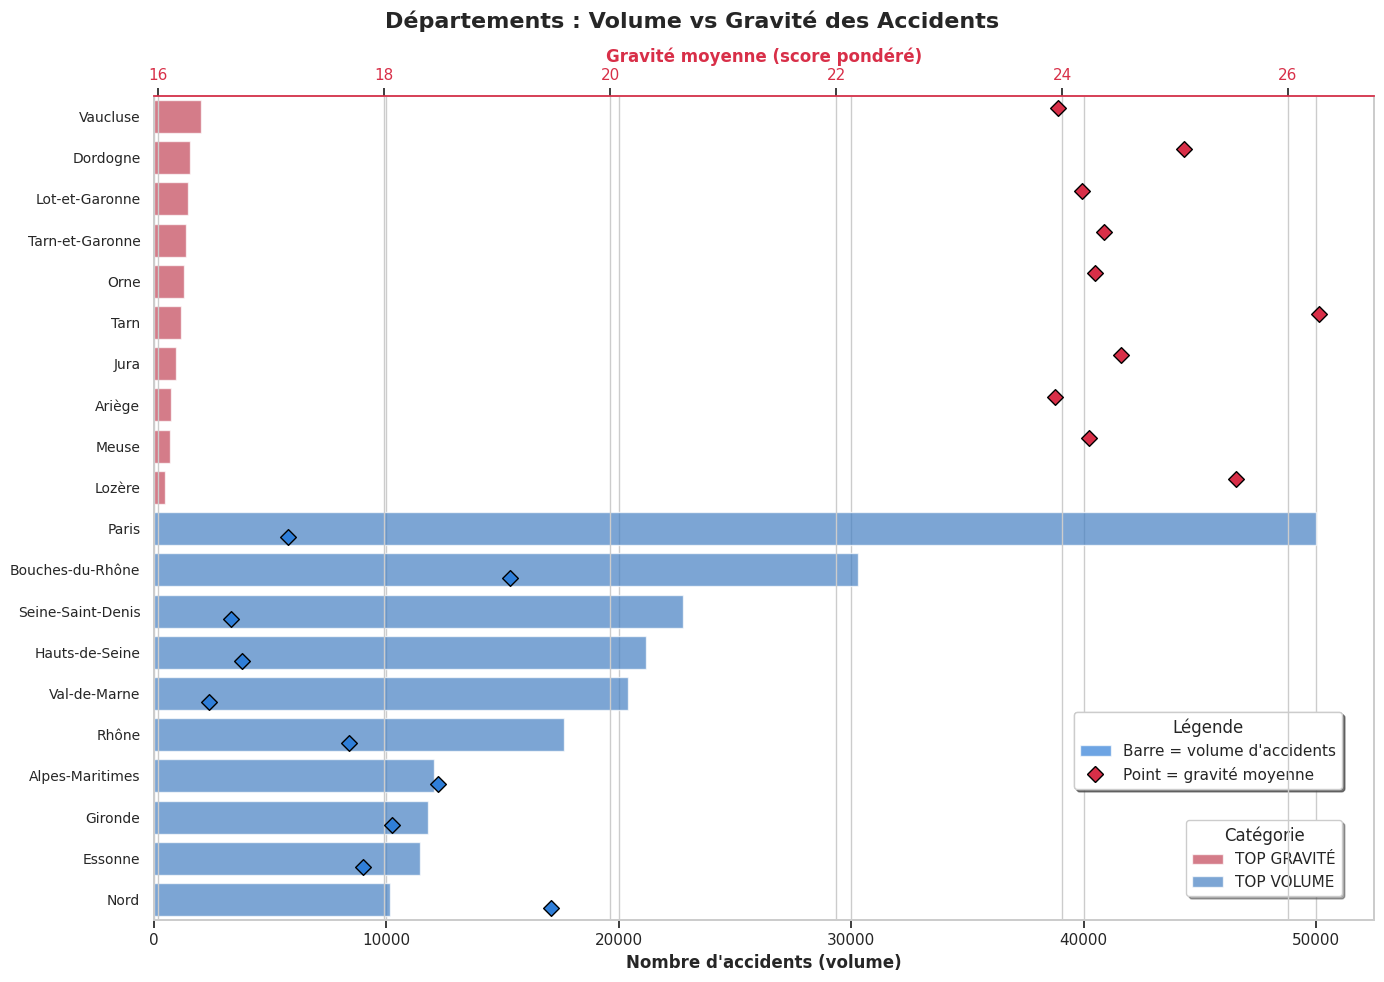

In [72]:
# Visualisation: Volume vs Gravité par département (dual-axis)
df = df_routes

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 10))

# Palette de couleurs
palette = {"TOP VOLUME": "#2F7ED8", "TOP GRAVITÉ": "#D82F48"}

# Barres horizontales pour le volume d'accidents
sns.barplot(
    data=df,
    y="nom_departement",
    x="nb_accidents",
    hue="categorie",
    palette=palette,
    orient="h",
    ax=ax1,
    alpha=0.7
)

# Configuration de ax1 (volume)
ax1.set_xlabel("Nombre d'accidents (volume)", fontsize=12, fontweight='bold')
ax1.set_ylabel("")
ax1.tick_params(axis='x', labelsize=11)
ax1.tick_params(axis='y', labelsize=10)

# Légende pour les catégories
cat_handles, cat_labels = ax1.get_legend_handles_labels()
cat_leg = ax1.legend(
    cat_handles,
    cat_labels,
    title="Catégorie",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    frameon=True,
    shadow=True
)
ax1.add_artist(cat_leg)

# Légende explicative des symboles
symbol_handles = [
    Patch(facecolor="#2F7ED8", alpha=0.7, label="Barre = volume d'accidents"),
    Line2D([0], [0], color="#000000", marker="D", linestyle="None",
           markerfacecolor="#D82F48", markeredgecolor="black",
           markersize=8, label="Point = gravité moyenne")
]
symbol_leg = ax1.legend(
    handles=symbol_handles,
    title="Légende",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.15),
    frameon=True,
    shadow=True
)
ax1.add_artist(symbol_leg)

# Création du deuxième axe (gravité)
ax2 = ax1.twiny()
sns.stripplot(
    data=df,
    y="nom_departement",
    x="gravite_moyenne",
    hue="categorie",
    palette=palette,
    ax=ax2,
    orient="h",
    dodge=True,
    marker="D",
    edgecolor="black",
    linewidth=1,
    size=8,
    legend=False
)

# Configuration de ax2 (gravité)
ax2.set_xlabel("Gravité moyenne (score pondéré)", fontsize=12, fontweight='bold', color='#D82F48')
ax2.tick_params(axis='x', labelcolor='#D82F48', labelsize=11)
ax2.spines['top'].set_color('#D82F48')

# Titre
plt.suptitle(
    "Départements : Volume vs Gravité des Accidents",
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

---

# 💡 Section 8 : Conclusions & Recommandations

## 🎯 Principaux Enseignements

### 📍 Géographie
- Les régions les plus peuplées concentrent logiquement le plus d'accidents
- Cependant, certains départements moins denses présentent des **taux de mortalité alarmants**
- **Recommandation** : Cibler les actions de prévention selon un double critère volume/gravité

### 🌦️ Conditions
- Contrairement aux idées reçues, **les conditions normales** (beau temps, plein jour) concentrent le plus d'accidents
- **Mais** : Les conditions dégradées (pluie, nuit) augmentent significativement la **gravité**
- Hors agglomération : risque de mortalité multiplié
- **Recommandation** : Adapter les limitations de vitesse selon les conditions météo/luminosité

### ⏰ Temporalité
- **Pics horaires** : 8h (trajet travail), 18h (retour), 2h du matin (soirées)
- **Jours critiques** : Vendredis et samedis soirs
- **Saisonnalité** : Été + week-ends = combinaison dangereuse
- **Recommandation** : Renforcer les contrôles durant ces périodes à risque

### 🔴 Cocktails Mortels
- Certaines combinaisons de facteurs créent des situations **extrêmement dangereuses**
- Exemples : Nuit + pluie + route nationale + hors agglo
- **Recommandation** : Signalétique renforcée et alertes ciblées pour ces configurations

### 📅 Effet Week-end Saisonnier
- Les **vendredis et samedis soirs d'été** entre 22h et 2h sont les périodes les plus critiques
- Les **dimanches soirs** de retours de week-end présentent aussi des pics
- **Recommandation** : Campagnes de prévention spécifiques avant les départs en week-end

---

## 🚦 Recommandations Stratégiques

### 1️⃣ Prévention Ciblée
- **Où** : Départements identifiés en quadrant "critique" (volume + gravité élevés)
- **Quand** : Vendredis et samedis soirs, période estivale
- **Comment** : Contrôles renforcés, radars pédagogiques

### 2️⃣ Infrastructure
- Amélioration de l'**éclairage** sur routes nationales hors agglomération
- **Signalétique dynamique** adaptée aux conditions météo
- Zones de repos renforcées sur axes à fort trafic week-end

### 3️⃣ Communication
- Campagnes **"Cocktails mortels"** : alertes grand public sur combinaisons dangereuses
- Application mobile avec **alertes en temps réel** basées sur l'analyse des facteurs
- Messages ciblés avant départs en week-end

### 4️⃣ Réglementation
- **Limitations variables** selon conditions (météo + luminosité)
- Renforcement des contrôles d'alcoolémie les vendredis/samedis soirs
- Sanctions alourdies pour excès de vitesse de nuit hors agglo

---

*Notebook de présentation - Analyse des accidents de la route - 2025*